# Laser Step-Down: Settling to New Steady States

**Run:** ~4-day laser power step-down, 2026-07-05 to 2026-07-09. The imaging laser
steps through 48 commanded levels (`lab_utils/laser_step_down.py`); radiation-pressure
torque tracks laser power, so at each held level the disk's spin frequency relaxes
toward a new steady state. Many levels were held for less than one damping time, so
most steps never fully settle -- the fits below handle that explicitly.

**What this notebook extracts, per detected step:**
- the steady-state frequency f_ss, via a fixed-γ fit that extrapolates reliably even
  for unsettled steps (γ locked to the free-decay value τ = 67.65 min measured in
  `spindown_20260702.ipynb`);
- a float-τ diagnostic fit -- on long holds, its agreement with 67.65 min is a direct
  test of the linear-drag assumption;
- a wide-band PSD cross-check per step (YAW vs the independent PIT channel) guarding
  against harmonic confusion in the extracted frequency;
- angular acceleration (df/dt) through each transition.

**Provenance notes (lessons already learned, kept short):**
- The Hilbert bandpass must clear the highest real rotation frequency: plateaus reach
  ~3.87 Hz and step 2's transient spin-up reaches ~7.1 Hz, so F_HIGH = 8 Hz. (An early
  F_HIGH = 3 Hz silently corrupted several steps -- caught by the PIT cross-check.)
- Powers are from the 2026-07-20 power-meter calibration (linear counts->mW law,
  `analysis/laser_calibration/pd_calibration.ipynb`). The PD trace is a good
  *relative* monitor but carries an etalon wiggle (+/-12 counts, worst at
  1500-1800 counts) -- it is NOT a clean absolute power proxy.
- Step table + fit results are saved to `laser_stepdown_steps.csv` for
  `laser_stepdown_stability.ipynb` and `laser_stepdown_forward_model.ipynb`.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert, welch
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d
import csv

In [2]:
# GPS -> UTC: GPS epoch is Jan 6 1980; 18 leap seconds as of 2025
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

# Each channel is split across two back-to-back export files, covering
# 2026-07-05 21:46 UTC -> 2026-07-09 20:05 UTC.
PD_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467582390_1467662710.h5',
]
YAW_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1467582390_1467662710.h5',
]
# PIT: independent readout axis, used only for the PSD cross-check.
PIT_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_1467582390_1467662710.h5',
]

STEP_TABLE_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'

# Free-decay damping, measured in spindown_20260702.ipynb (PIT, post-drive-off peak
# to libration onset). Fixed in the primary fits.
TAU_FREE_MIN = 67.65
GAMMA_FREE   = 1.0 / (TAU_FREE_MIN * 60.0)   # s^-1

# Detected plateaus <-> operator's step-down log (matched by held duration; see the
# correspondence table in Section 2).
# power_mw: MEASURED with a power meter on 2026-07-20 (in front of the chamber; see
# analysis/laser_calibration/pd_calibration.ipynb). The laser's counts->power law is
# linear (11.87 uW/count above a 735-count threshold) and sub-1% repeatable, so these
# apply retroactively to this run. They replace the operator log's rough values,
# which were ~1.25x high at the top end and 27x wrong at 800 counts.
STEP_LOG_INFO = {
    2:  dict(counts=1800, power_mw=12.52, log_step='1/48',  log_wait_min=40.8),
    3:  dict(counts=1600, power_mw=10.34, log_step='5/48',  log_wait_min=1192.9),
    4:  dict(counts=1550, power_mw=9.88,  log_step='6/48',  log_wait_min=158.7),
    5:  dict(counts=1500, power_mw=9.21,  log_step='7/48',  log_wait_min=72.6),
    6:  dict(counts=1400, power_mw=7.97,  log_step='9/48',  log_wait_min=89.1),
    7:  dict(counts=1300, power_mw=6.66,  log_step='11/48', log_wait_min=1086.0),
    8:  dict(counts=1200, power_mw=5.39,  log_step='13/48', log_wait_min=132.8),
    11: dict(counts=1000, power_mw=3.04,  log_step='17/48', log_wait_min=1053.6),
}

def step_label(i, s):
    info = STEP_LOG_INFO.get(i)
    if info:
        return f"{info['counts']} counts ({info['power_mw']:.2f} mW)"
    if i <= 1:
        return f"PD={s['pd_level']:.0f} (pre-sequence, before log step 1/48)"
    return f"PD={s['pd_level']:.0f} (unmatched tail sub-step)"

## 1. PD Trace Overview (Full Span)

PD: 339,520 points  2026-07-05 21:46:12+00:00 -> 2026-07-09 20:04:51+00:00


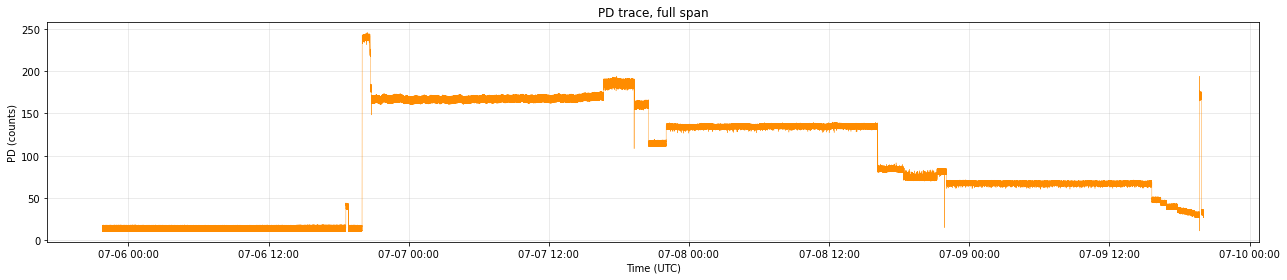

In [3]:
def load_strided_multi(files, stride):
    # Strided read across back-to-back HDF5 exports (no anti-alias filter --
    # for visual inspection / step-level detection only)
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                y_seg = dset[ix: ix + n: stride].astype(np.float32)
                t_seg = gps0 + np.arange(len(y_seg)) * stride / fs
                t_list.append(t_seg)
                y_list.append(y_seg)
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

t_pd, y_pd = load_strided_multi(PD_FILES, 1024)   # 1 Hz effective
print(f"PD: {len(y_pd):,} points  {gps_to_dt(t_pd[0])} -> {gps_to_dt(t_pd[-1])}")

fig, ax = plt.subplots(figsize=(18, 4))
ax.plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('PD (counts)')
ax.set_title('PD trace, full span')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Step Detection
Steps are detected directly from the PD trace (no setpoint channel was exported):
5-min bins are "stable" if their std < `STD_THRESH`; consecutive stable bins whose
medians agree within `LEVEL_TOL` merge into one plateau; plateaus shorter than
`MIN_DURATION_H` are discarded as transition transients.

In [4]:
BIN_S          = 300   # 5 min bins
STD_THRESH     = 5.0   # PD units -- noisier bins are mid-transition
LEVEL_TOL      = 4.0   # PD units -- resolves the closely-spaced low-power sub-steps
MIN_DURATION_H = 0.3   # most logged steps were held tens of minutes, not hours

t0 = t_pd[0]
bin_idx = ((t_pd - t0) // BIN_S).astype(int)
n_bins = bin_idx.max() + 1
bin_med = np.full(n_bins, np.nan)
bin_std = np.full(n_bins, np.nan)
bin_t0  = t0 + np.arange(n_bins) * BIN_S
for b in range(n_bins):
    m = bin_idx == b
    if m.sum() > 0:
        bin_med[b] = np.median(y_pd[m])
        bin_std[b] = y_pd[m].std()

stable = (bin_std < STD_THRESH) & np.isfinite(bin_med)

segments = []
cur_start, cur_levels = None, []
for b in range(n_bins):
    if stable[b]:
        if cur_start is None:
            cur_start, cur_levels = b, [bin_med[b]]
        elif abs(bin_med[b] - np.median(cur_levels)) < LEVEL_TOL:
            cur_levels.append(bin_med[b])
        else:
            segments.append((cur_start, b - 1, np.median(cur_levels)))
            cur_start, cur_levels = b, [bin_med[b]]
    else:
        if cur_start is not None:
            segments.append((cur_start, b - 1, np.median(cur_levels)))
            cur_start, cur_levels = None, []
if cur_start is not None:
    segments.append((cur_start, n_bins - 1, np.median(cur_levels)))

steps = []
for s0, s1, lvl in segments:
    dur_h = (s1 - s0 + 1) * BIN_S / 3600
    if dur_h >= MIN_DURATION_H:
        steps.append(dict(pd_level=lvl, t_start_gps=bin_t0[s0],
                          t_end_gps=bin_t0[s1] + BIN_S, duration_h=dur_h))

print(f"{len(steps)} plateaus detected (>= {MIN_DURATION_H} h):\n")
for i, s in enumerate(steps):
    print(f"  [{i:2d}] {step_label(i, s):42s} "
          f"{gps_to_dt(s['t_start_gps'])} -> {gps_to_dt(s['t_end_gps'])}  ({s['duration_h']*60:.0f} min)")

print("\nNOTE: steps [0]-[1] are the pre-sequence baseline (same level, split by a noise"
      "\nblip). Steps [9], [10], [12]-[14] are real tail sub-steps but sit too close in PD"
      "\nlevel to confidently assign specific logged count values. The data ends"
      "\nmid-transition after the last plateau.")

15 plateaus detected (>= 0.3 h):

  [ 0] PD=14 (pre-sequence, before log step 1/48) 2026-07-05 21:46:12+00:00 -> 2026-07-06 18:36:12+00:00  (1250 min)
  [ 1] PD=14 (pre-sequence, before log step 1/48) 2026-07-06 18:51:12+00:00 -> 2026-07-06 19:56:12+00:00  (65 min)
  [ 2] 1800 counts (12.52 mW)                     2026-07-06 20:01:12+00:00 -> 2026-07-06 20:41:12+00:00  (40 min)
  [ 3] 1600 counts (10.34 mW)                     2026-07-06 20:51:12+00:00 -> 2026-07-07 16:41:12+00:00  (1190 min)
  [ 4] 1550 counts (9.88 mW)                      2026-07-07 16:46:12+00:00 -> 2026-07-07 19:16:12+00:00  (150 min)
  [ 5] 1500 counts (9.21 mW)                      2026-07-07 19:21:12+00:00 -> 2026-07-07 20:31:12+00:00  (70 min)
  [ 6] 1400 counts (7.97 mW)                      2026-07-07 20:36:12+00:00 -> 2026-07-07 22:01:12+00:00  (85 min)
  [ 7] 1300 counts (6.66 mW)                      2026-07-07 22:06:12+00:00 -> 2026-07-08 16:06:12+00:00  (1080 min)
  [ 8] 1200 counts (5.39 mW)           

### Correspondence with the operator's step-down log

Matched by held duration (the only three ~18-20 h holds are unambiguous; the shorter
ones match logged wait times closely):

| log step | counts | power | logged wait | detected step | detected duration |
|---|---|---|---|---|---|
| 1/48  | 1800 | ~15.10 mW | 40.8 min             | [2]  | 40 min |
| 5/48  | 1600 | ~12.92 mW | 1192.9 min = 19.88 h | [3]  | 19.8 h |
| 6/48  | 1550 | ~12.23 mW | 158.7 min            | [4]  | 150 min |
| 7/48  | 1500 | ~11.46 mW | 72.6 min             | [5]  | 70 min |
| 9/48  | 1400 | ~10.01 mW | 89.1 min             | [6]  | 85 min |
| 11/48 | 1300 | ~8.49 mW  | 1086.0 min = 18.10 h | [7]  | 18.0 h |
| 13/48 | 1200 | ~7.09 mW  | 132.8 min            | [8]  | 130 min |
| 17/48 | 1000 | ~3.41 mW  | 1053.6 min = 17.56 h | [11] | 17.5 h |

(Log steps 8/48 and 10/48 had 0.0 min waits -- correctly no plateau detected between.)

**Update 2026-07-20:** the log's mW values above are superseded by the power-meter calibration (`analysis/laser_calibration/pd_calibration.ipynb`); `STEP_LOG_INFO` now carries the measured powers.

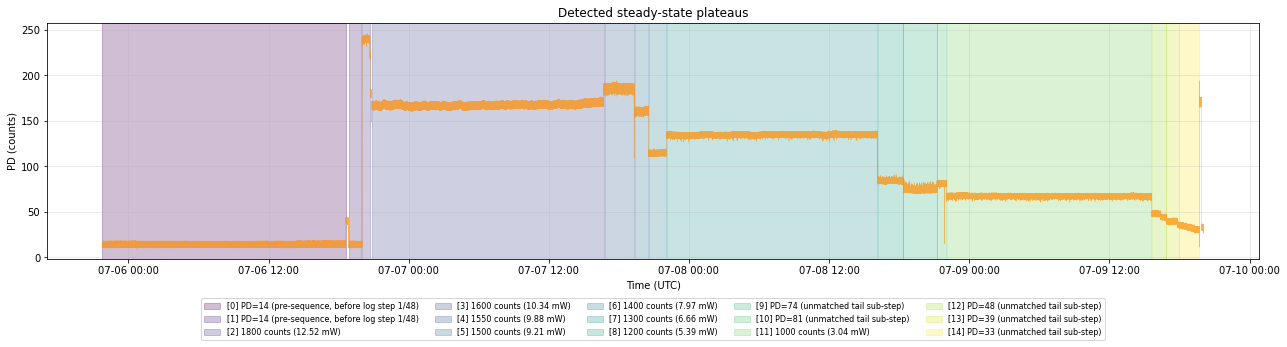

In [5]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange', alpha=0.7)
colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
for i, s in enumerate(steps):
    ax.axvspan(gps_to_dt(s['t_start_gps']), gps_to_dt(s['t_end_gps']),
               color=colors[i], alpha=0.25, label=f"[{i}] {step_label(i, s)}")
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('PD (counts)')
ax.set_title('Detected steady-state plateaus')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.legend(fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. YAW Spin Frequency (Full Span)
Decimate to 64 Hz -> zero-phase Butterworth bandpass -> Hilbert transform ->
30 s-smoothed instantaneous frequency. `F_HIGH = 8 Hz` clears the highest real
rotation frequency in this run (~7.1 Hz during step 2's transient spin-up;
plateaus top out at ~3.87 Hz, confirmed against PIT in Section 5).

In [6]:
def load_channel_multi(files, fs_out=64.0):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            dec  = int(round(fs / fs_out))
            for gps0, ix, n in zip(segs, idxs, lens):
                seg = dset[ix:ix + n].astype(np.float64)
                if dec == 16:
                    seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                elif dec > 1:
                    seg = decimate(seg, dec, zero_phase=True)
                t_seg = gps0 + np.arange(len(seg)) / fs_out
                t_list.append(t_seg)
                y_list.append(seg)
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    return (uniform_filter1d(inst_freq,     size=win),
            uniform_filter1d(envelope[:-1], size=win),
            dt / 2)

FS_RING = 64.0
F_LOW, F_HIGH = 0.02, 8.0   # Hz -- see Section 3 note
SMOOTH_SEC = 30.0

print("Loading YAW at 64 Hz across the full span (takes a few minutes)...")
t_yaw, y_yaw = load_channel_multi(YAW_FILES, fs_out=FS_RING)
print(f"YAW: {len(y_yaw):,} samples  {gps_to_dt(t_yaw[0])} -> {gps_to_dt(t_yaw[-1])}")

sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
t_freq_yaw = t_yaw[:-1] + dt_half
del y_yaw, y_yaw_f
print(f"freq range: {freq_yaw.min():.3f} - {freq_yaw.max():.3f} Hz")

Loading YAW at 64 Hz across the full span (takes a few minutes)...
YAW: 21,729,280 samples  2026-07-05 21:46:12+00:00 -> 2026-07-09 20:04:51.984375+00:00
freq range: 0.006 - 7.877 Hz


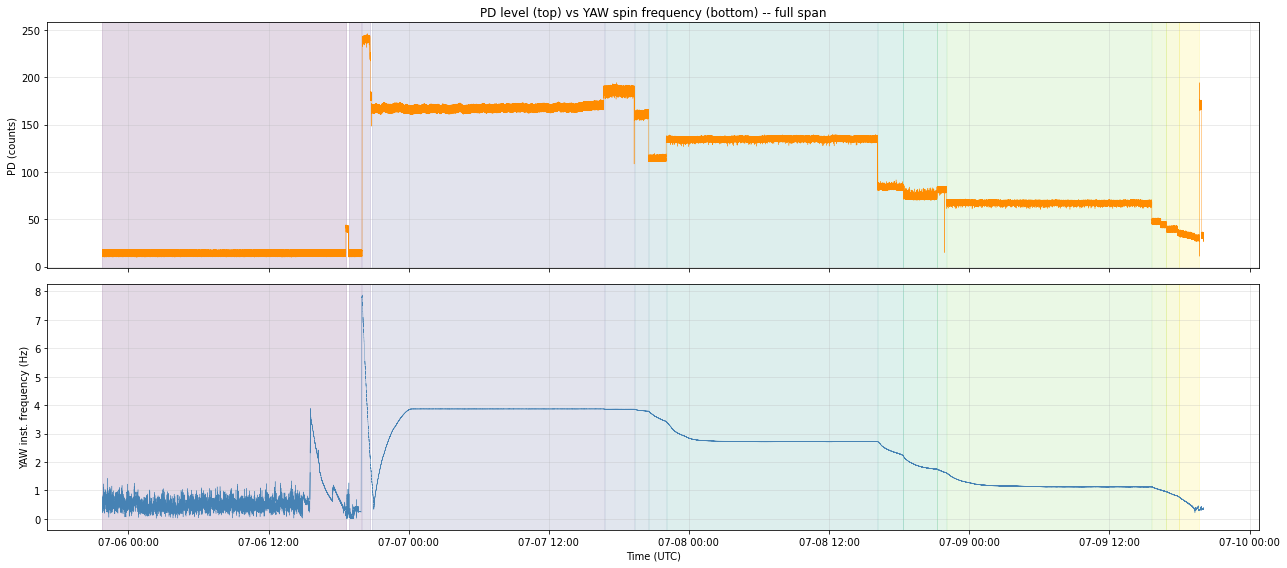

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange')
axes[0].set_ylabel('PD (counts)')
axes[0].set_title('PD level (top) vs YAW spin frequency (bottom) -- full span')
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_freq_yaw], freq_yaw, linewidth=0.4, color='steelblue')
axes[1].set_ylabel('YAW inst. frequency (Hz)')
axes[1].set_xlabel('Time (UTC)')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    for i, s in enumerate(steps):
        ax.axvspan(gps_to_dt(s['t_start_gps']), gps_to_dt(s['t_end_gps']),
                   color=colors[i], alpha=0.15)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
plt.tight_layout()
plt.show()

## 4. Per-Step Fits
**Primary fit (fixed γ):** `f(t) = f_ss + A * exp(-γ_free t)` with γ_free = 1/(67.65 min)
locked to the measured free-decay rate. For linear drag with an Ω-independent drive
torque, every relaxation happens at the free-decay rate -- so f_ss is well-constrained
even for steps held << 1 τ (extrapolation along the known relaxation curve).

**Diagnostic fit (float τ):** same model with τ free and f_ss fixed to the tail median.
Meaningful only on long holds (≥ ~2 τ); its agreement with 67.65 min there is a direct
test of the linear-drag assumption. On short holds it is degenerate -- do not read
those τ values as physics.

**Fit windows:** each fit starts at the transition extremum (transitions overshoot, so
fitting from the previous plateau's end would be meaningless), plus per-step start
trims chosen by inspecting the data:
- step 2: +500 s (skips the early spin-up region; the fit then covers the clean decay
  from the ~7 Hz peak, per the 0.14-0.7 h window identified by eye);
- step 5: +300 s (the first ~4 min of its window is still flat at step 4's steady
  state -- the transition hadn't started yet).

Steps [0]->[1] (same level) are skipped. Step 2 remains low-confidence regardless of
window: it has failed every independent check (PSD mismatch, unphysical extrapolation).

In [8]:
def exp_decay_ss(t, A, gamma, f_ss):
    return f_ss + A * np.exp(-gamma * t)

def model_fixed_gamma(t, A, f_ss):
    return f_ss + A * np.exp(-GAMMA_FREE * t)

MIN_STEP_PD_DELTA = 5.0        # PD units -- below this it's the same level, not a step
FIT_TRIM_START_S  = {2: 500, 5: 300}   # per-step start trims (see markdown above)

fit_results = []
for i in range(1, len(steps)):
    prev, cur = steps[i - 1], steps[i]
    if abs(cur['pd_level'] - prev['pd_level']) < MIN_STEP_PD_DELTA:
        print(f"Step {i} ({step_label(i, cur)}): skipped -- same level as previous step")
        continue

    t_prev_end, t_new_start, t_new_end = prev['t_end_gps'], cur['t_start_gps'], cur['t_end_gps']

    tail_start = t_new_end - 0.25 * (t_new_end - t_new_start)
    tail_mask  = (t_freq_yaw >= tail_start) & (t_freq_yaw <= t_new_end)
    f_tail     = np.median(freq_yaw[tail_mask])

    trans_mask = (t_freq_yaw >= t_prev_end) & (t_freq_yaw <= t_new_start)
    t_trans, f_trans = t_freq_yaw[trans_mask], freq_yaw[trans_mask]
    t_peak = t_trans[np.argmax(np.abs(f_trans - f_tail))] if len(f_trans) else t_prev_end
    t_start_fit = t_peak + FIT_TRIM_START_S.get(i, 0)

    fit_mask = (t_freq_yaw >= t_start_fit) & (t_freq_yaw <= t_new_end)
    t_fit, f_fit, env_fit = t_freq_yaw[fit_mask], freq_yaw[fit_mask], env_yaw[fit_mask]

    # Light cut on extreme envelope spikes only (Hilbert glitches)
    env_hi = np.percentile(env_fit, 99.5)
    good = env_fit <= env_hi
    t_fit, f_fit = t_fit[good], f_fit[good]
    if len(f_fit) < 20:
        print(f"Step {i} ({step_label(i, cur)}): skipped -- only {len(f_fit)} points")
        continue

    ts = t_fit - t_fit[0]
    hold_in_tau = ts[-1] / (TAU_FREE_MIN * 60.0)

    # -- Primary: fixed gamma, fit (A, f_ss) --------------------------------------
    popt_fx, pcov_fx = curve_fit(model_fixed_gamma, ts, f_fit,
                                  p0=[f_fit[0] - f_fit[-1], f_fit[-1]], maxfev=20000)
    A_fx, fss_fx = popt_fx
    fss_fx_err = np.sqrt(np.diag(pcov_fx))[1]
    resid_fx = f_fit - model_fixed_gamma(ts, *popt_fx)
    f_end_model = model_fixed_gamma(ts[-1], A_fx, fss_fx)

    # -- Diagnostic: float tau, f_ss fixed to tail median -------------------------
    tau_fl, tau_fl_err, A_fl, resid_fl_std = np.nan, np.nan, np.nan, np.nan
    try:
        popt_fl, pcov_fl = curve_fit(lambda t, A, g: exp_decay_ss(t, A, g, f_tail),
                                      ts, f_fit, p0=[f_fit[0] - f_tail, 1/3600.0],
                                      maxfev=20000)
        A_fl, gamma_fl = popt_fl
        tau_fl = 1.0 / gamma_fl
        tau_fl_err = np.sqrt(np.diag(pcov_fl))[1] / gamma_fl**2
        resid_fl_std = (f_fit - exp_decay_ss(ts, A_fl, gamma_fl, f_tail)).std()
    except RuntimeError:
        pass

    fit_results.append(dict(
        step=i, pd_level=cur['pd_level'], hold_in_tau=hold_in_tau,
        f_tail=f_tail, A_fx=A_fx, fss_fx=fss_fx, fss_fx_err=fss_fx_err,
        resid_fx_std=resid_fx.std(), f_end_model=f_end_model,
        tau_fl=tau_fl, tau_fl_err=tau_fl_err, A_fl=A_fl, resid_fl_std=resid_fl_std,
        t_fit_start=t_fit[0], t_fit_end=t_fit[-1], n_points=len(f_fit),
        t_fit=t_fit, f_fit=f_fit,
    ))

    print(f"Step {i:2d} ({step_label(i, cur)}): hold={hold_in_tau:.2f} tau | "
          f"f_ss(fixed-g)={fss_fx:.4f} Hz (resid {resid_fx.std():.4f}) | "
          f"tau(float)={tau_fl/60:.1f} min")

Step 1 (PD=14 (pre-sequence, before log step 1/48)): skipped -- same level as previous step
Step  2 (1800 counts (12.52 mW)): hold=0.47 tau | f_ss(fixed-g)=-4.7823 Hz (resid 0.0071) | tau(float)=12.1 min
Step  3 (1600 counts (10.34 mW)): hold=17.59 tau | f_ss(fixed-g)=3.8819 Hz (resid 0.0756) | tau(float)=66.5 min
Step  4 (1550 counts (9.88 mW)): hold=2.29 tau | f_ss(fixed-g)=3.8549 Hz (resid 0.0028) | tau(float)=5.2 min
Step  5 (1500 counts (9.21 mW)): hold=1.03 tau | f_ss(fixed-g)=3.7499 Hz (resid 0.0033) | tau(float)=21.1 min
Step  6 (1400 counts (7.97 mW)): hold=1.32 tau | f_ss(fixed-g)=3.3081 Hz (resid 0.0042) | tau(float)=33.0 min
Step  7 (1300 counts (6.66 mW)): hold=16.04 tau | f_ss(fixed-g)=2.7180 Hz (resid 0.0063) | tau(float)=66.4 min
Step  8 (1200 counts (5.39 mW)): hold=1.97 tau | f_ss(fixed-g)=2.1819 Hz (resid 0.0103) | tau(float)=43.6 min
Step  9 (PD=74 (unmatched tail sub-step)): hold=2.59 tau | f_ss(fixed-g)=1.7078 Hz (resid 0.0058) | tau(float)=48.8 min
Step 10 (PD=81

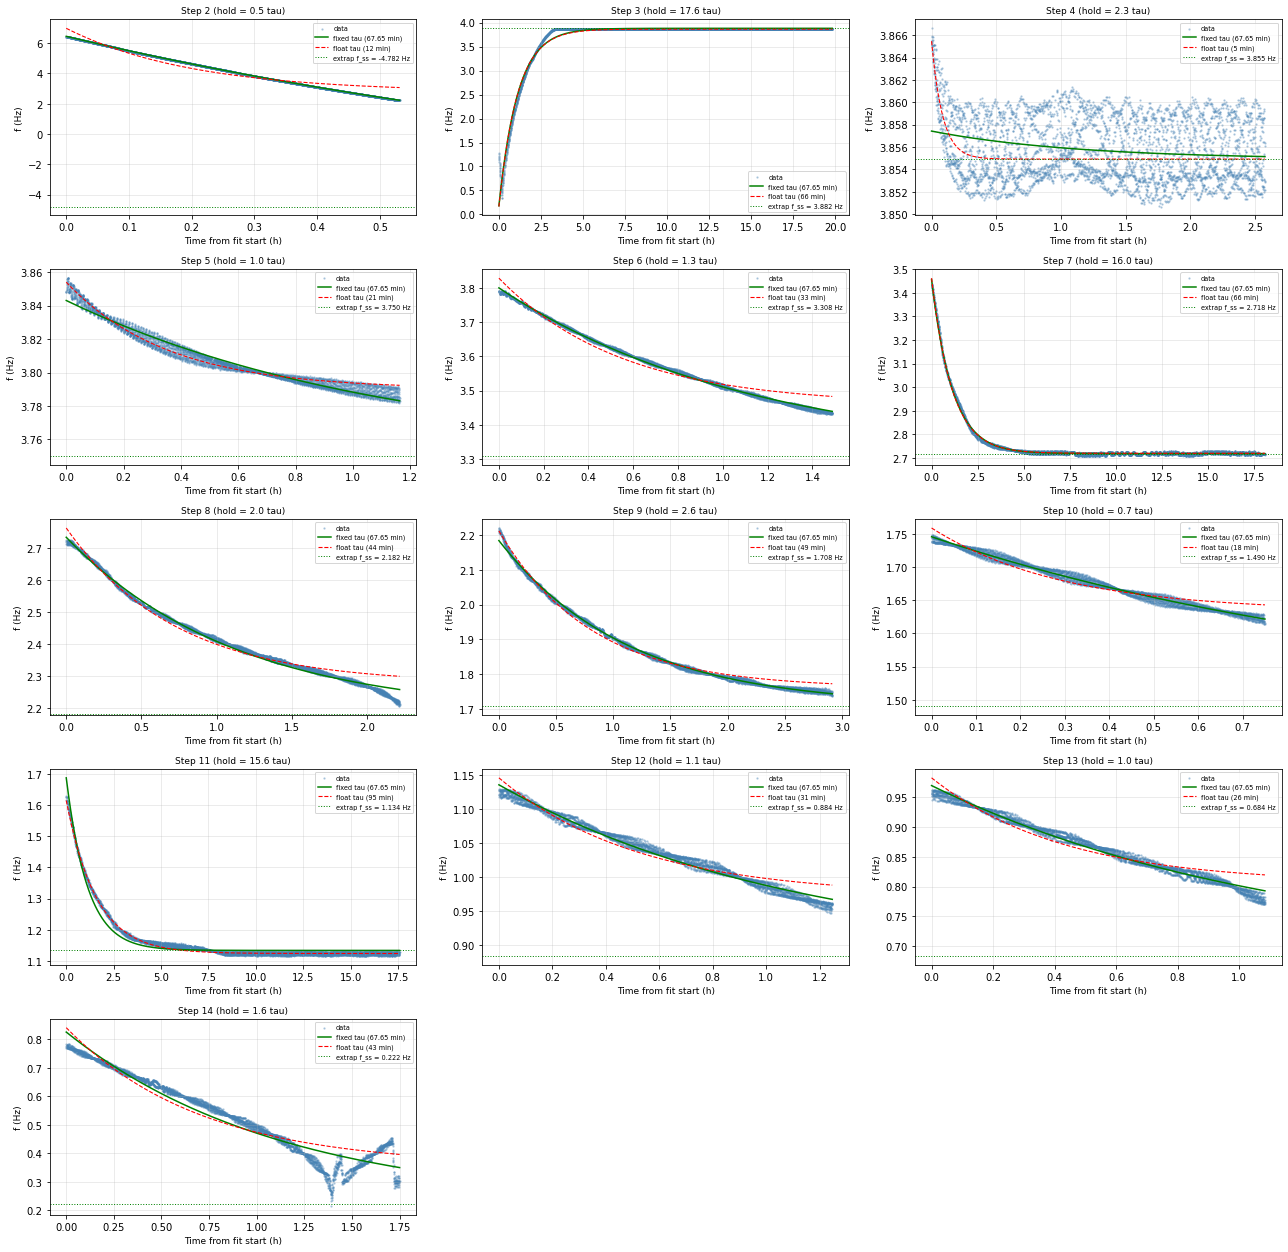

In [9]:
n = len(fit_results)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, r in zip(axes, fit_results):
    ts = r['t_fit'] - r['t_fit_start']
    th = ts / 3600.0
    stride = max(1, len(ts) // 4000)
    ax.scatter(th[::stride], r['f_fit'][::stride], s=2, alpha=0.3, color='steelblue',
               label='data')
    tc = np.linspace(0, ts[-1], 600)
    ax.plot(tc / 3600, model_fixed_gamma(tc, r['A_fx'], r['fss_fx']), 'g-', lw=1.5,
            label=f"fixed tau ({TAU_FREE_MIN} min)")
    if np.isfinite(r['tau_fl']):
        ax.plot(tc / 3600, exp_decay_ss(tc, r['A_fl'], 1/r['tau_fl'], r['f_tail']),
                'r--', lw=1.1, label=f"float tau ({r['tau_fl']/60:.0f} min)")
    ax.axhline(r['fss_fx'], color='green', ls=':', lw=1,
               label=f"extrap f_ss = {r['fss_fx']:.3f} Hz")
    ax.set_title(f"Step {r['step']} (hold = {r['hold_in_tau']:.1f} tau)", fontsize=9)
    ax.set_xlabel('Time from fit start (h)', fontsize=9)
    ax.set_ylabel('f (Hz)', fontsize=9)
    ax.legend(fontsize=6.5, loc='best')
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. PSD Cross-Check (Harmonic Guard)
Per step: unfiltered 128 s x 5-average Welch PSDs from the END of each plateau, for
YAW and the independent PIT axis. Checks, per step:
1. YAW and PIT agree on the dominant peak (two axes agreeing = real rotation);
2. the fixed-γ model evaluated at the plateau end lands on that peak's fundamental --
   not its half or double (harmonic-confusion guard). The extrapolated f_ss itself
   can't be PSD-checked on unsettled steps, since the data never reached it.

In [10]:
def load_channel_window(files, gps_t0, gps_t1, fs_out=64.0):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            dec  = int(round(fs / fs_out))
            for gps0, ix, n in zip(segs, idxs, lens):
                gps1 = gps0 + n / fs
                if gps1 < gps_t0 or gps0 > gps_t1:
                    continue
                seg = dset[ix:ix + n].astype(np.float64)
                if dec == 16:
                    seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)
                elif dec > 1:
                    seg = decimate(seg, dec, zero_phase=True)
                t_seg = gps0 + np.arange(len(seg)) / fs_out
                mask = (t_seg >= gps_t0) & (t_seg <= gps_t1)
                t_list.append(t_seg[mask]); y_list.append(seg[mask])
    if not t_list:
        return np.array([]), np.array([])
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

PSD_SEG_S, PSD_NAVG = 128, 5
PSD_WIN_S = PSD_SEG_S * PSD_NAVG
CROSS_CHANNEL_TOL = 0.02   # Hz

def global_peak(freqs, psd, band=(0.05, 10)):
    m = (freqs > band[0]) & (freqs < band[1])
    j = np.argmax(psd[m])
    return freqs[m][j], psd[m][j]

psd_results = []
for r in fit_results:
    i = r['step']
    t1 = steps[i]['t_end_gps']
    t0 = t1 - PSD_WIN_S
    t_yw, y_yw = load_channel_window(YAW_FILES, t0, t1, fs_out=FS_RING)
    t_pt, y_pt = load_channel_window(PIT_FILES, t0, t1, fs_out=FS_RING)
    if len(y_yw) < PSD_WIN_S * FS_RING * 0.9 or len(y_pt) < PSD_WIN_S * FS_RING * 0.9:
        print(f"Step {i}: insufficient data for PSD snapshot -- skipped")
        continue
    y_yw = y_yw - y_yw.mean()
    y_pt = y_pt - y_pt.mean()
    freqs, psd_yw = welch(y_yw, fs=FS_RING, nperseg=int(PSD_SEG_S * FS_RING),
                          noverlap=0, scaling='density')
    _, psd_pt = welch(y_pt, fs=FS_RING, nperseg=int(PSD_SEG_S * FS_RING),
                       noverlap=0, scaling='density')

    f_glob, _ = global_peak(freqs, psd_yw)
    f_glob_pit, _ = global_peak(freqs, psd_pt)

    cands = {'fund': f_glob, 'half': f_glob / 2, '2x': f_glob * 2}
    nearest = min(cands, key=lambda k: abs(cands[k] - r['f_end_model']))

    flags = []
    if abs(f_glob - r['f_end_model']) > 0.1 and nearest == 'fund':
        flags.append("plateau-end freq far from PSD peak")
    if nearest != 'fund':
        flags.append(f"nearest PSD {nearest} -- possible harmonic confusion")
    if abs(f_glob - f_glob_pit) > CROSS_CHANNEL_TOL:
        flags.append("YAW/PIT DISAGREE")

    psd_results.append(dict(step=i, freqs=freqs, psd=psd_yw, psd_pit=psd_pt,
                             f_global=f_glob, f_global_pit=f_glob_pit,
                             nearest=nearest, flags=flags))
    flag_str = ("  <-- " + "; ".join(flags)) if flags else ""
    print(f"Step {i:2d}: plateau-end model f={r['f_end_model']:.4f} Hz | "
          f"YAW peak {f_glob:.4f} | PIT peak {f_glob_pit:.4f}{flag_str}")

Step  2: plateau-end model f=2.2303 Hz | YAW peak 2.3359 | PIT peak 2.3359  <-- plateau-end freq far from PSD peak
Step  3: plateau-end model f=3.8819 Hz | YAW peak 3.8672 | PIT peak 3.8672
Step  4: plateau-end model f=3.8551 Hz | YAW peak 3.8516 | PIT peak 3.8516
Step  5: plateau-end model f=3.7831 Hz | YAW peak 3.7891 | PIT peak 3.7891
Step  6: plateau-end model f=3.4396 Hz | YAW peak 3.4453 | PIT peak 3.4453
Step  7: plateau-end model f=2.7180 Hz | YAW peak 2.7188 | PIT peak 2.7188
Step  8: plateau-end model f=2.2592 Hz | YAW peak 2.2578 | PIT peak 2.2578
Step  9: plateau-end model f=1.7436 Hz | YAW peak 1.7500 | PIT peak 1.7500
Step 10: plateau-end model f=1.6215 Hz | YAW peak 1.6328 | PIT peak 1.6328
Step 11: plateau-end model f=1.1341 Hz | YAW peak 1.1250 | PIT peak 1.1250
Step 12: plateau-end model f=0.9676 Hz | YAW peak 0.9688 | PIT peak 0.9688
Step 13: plateau-end model f=0.7929 Hz | YAW peak 0.8047 | PIT peak 0.8047
Step 14: plateau-end model f=0.3499 Hz | YAW peak 0.4062 | P

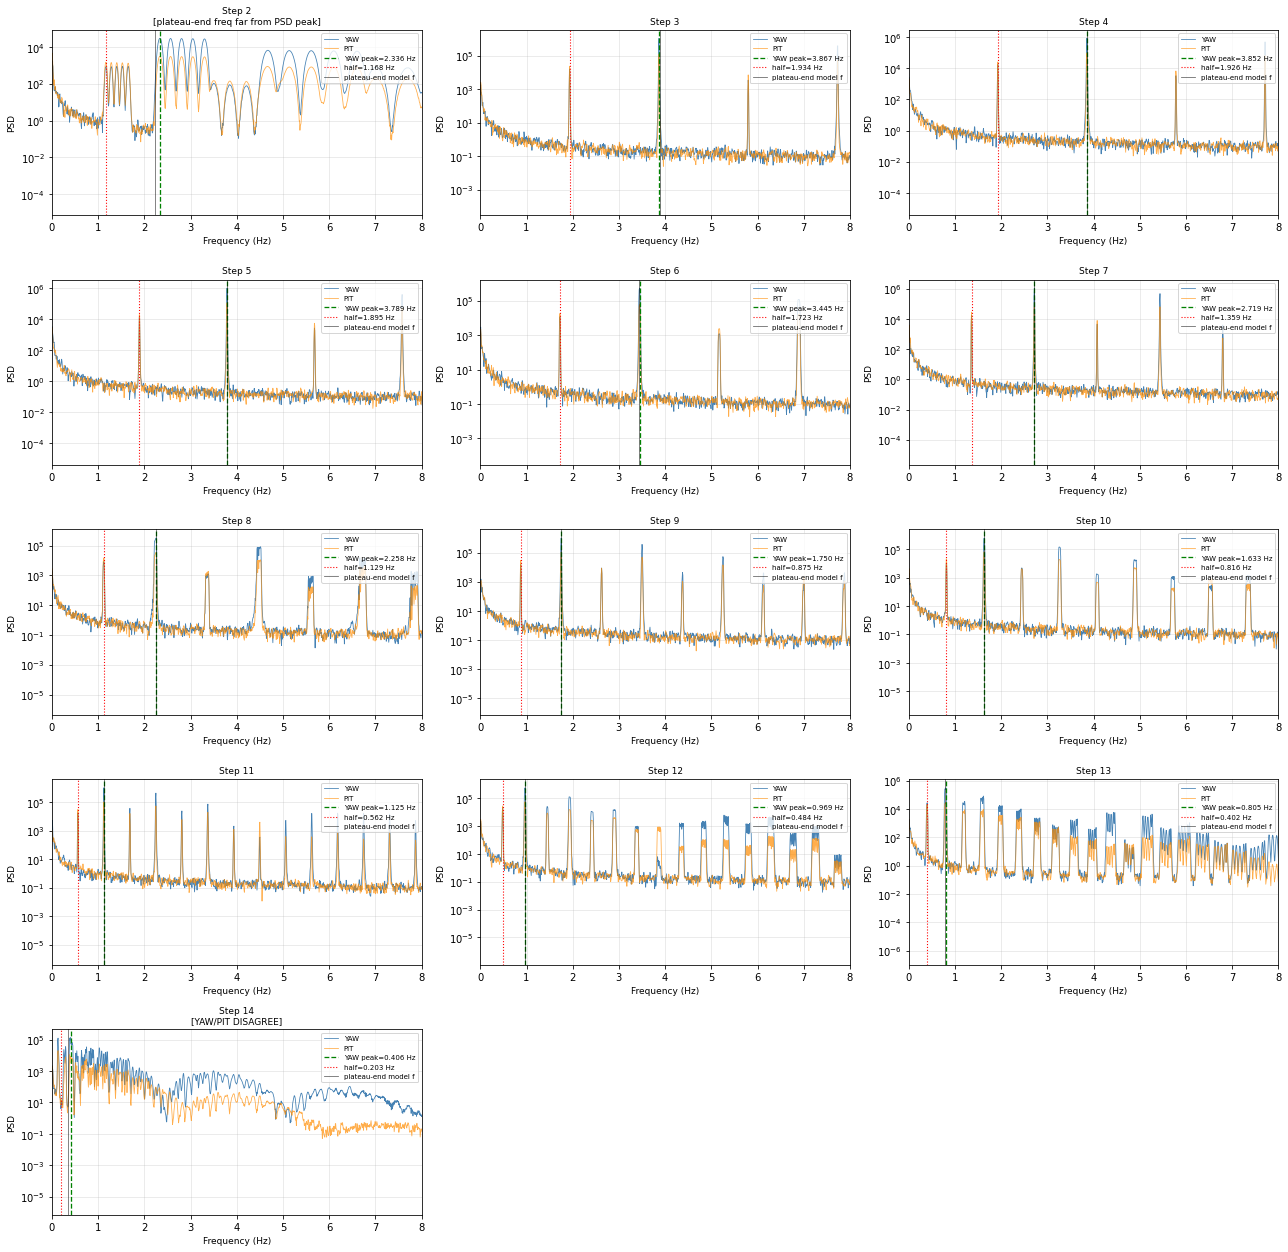

In [11]:
n = len(psd_results)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).ravel()

fit_by_step = {r['step']: r for r in fit_results}
for ax, pr in zip(axes, psd_results):
    ax.semilogy(pr['freqs'], pr['psd'], color='steelblue', lw=0.8, label='YAW')
    ax.semilogy(pr['freqs'], pr['psd_pit'], color='darkorange', lw=0.8, alpha=0.7, label='PIT')
    ax.axvline(pr['f_global'], color='green', ls='--', lw=1.3,
               label=f"YAW peak={pr['f_global']:.3f} Hz")
    ax.axvline(pr['f_global'] / 2, color='red', ls=':', lw=1.1,
               label=f"half={pr['f_global']/2:.3f} Hz")
    ax.axvline(fit_by_step[pr['step']]['f_end_model'], color='black', ls='-', lw=0.8,
               alpha=0.6, label='plateau-end model f')
    ax.set_xlim(0, 8)
    title = f"Step {pr['step']}"
    if pr['flags']:
        title += "\n[" + ", ".join(pr['flags']) + "]"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Frequency (Hz)', fontsize=9)
    ax.set_ylabel('PSD', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Detection Latency and Power Sensitivity
Answers "how quickly can we see a change?" as a signal-vs-noise question, in three parts:

1. **Noise floors.** σ_f(T) and σ_a(T) -- the frequency and angular-acceleration noise
   as a function of averaging time T -- measured from the settled tails of the three
   long holds (steps 3, 7, 11), using the fixed-γ fit residuals (the fit removes the
   true relaxation; the derivative of these residuals IS the acceleration noise).
2. **Per-step detection latency.** Each step's initial acceleration a₀ = |A|·γ from
   the primary fit (in Hz/s and rad/s²), and the shortest averaging time at which the
   response exceeds 5× the corresponding noise floor -- in the acceleration channel
   (watching df/dt) and the frequency channel (watching Δf accumulate).
3. **Minimum detectable power step vs response time.** The noise floors converted to
   power units via the torque calibration κ from `laser_stepdown_forward_model.ipynb`:
   fast detection is acceleration-limited, long-integration detection is
   frequency-limited. This is the empirical "what optical power am I sensitive to,
   at what latency" -- from measured noise, not thermal-model projections.

In [12]:
# -- 6.1 Noise floors vs averaging time -------------------------------------------
# Measured from the settled tails (last 50%) of the long holds: fixed-gamma fit
# residuals, so true relaxation dynamics are removed and what's left is measurement
# noise + unmodeled wander. sigma_f: std of T-long block means of the residual.
# sigma_a: std of d/dt of the T-smoothed residual (edges trimmed).
T_AVGS = np.array([30, 60, 120, 300, 600, 1200, 3600])   # s
LONG_STEPS = [3, 7, 11]

sigma_f_tbl, sigma_a_tbl = [], []
for T in T_AVGS:
    sf_list, sa_list = [], []
    for r in fit_results:
        if r['step'] not in LONG_STEPS:
            continue
        ts = r['t_fit'] - r['t_fit_start']
        resid = r['f_fit'] - model_fixed_gamma(ts, r['A_fx'], r['fss_fx'])
        half = len(resid) // 2
        res, tss = resid[half:], ts[half:]
        n_blk = int(T * FS_RING)
        if len(res) < 4 * n_blk:
            continue
        nb = len(res) // n_blk
        blocks = res[:nb * n_blk].reshape(nb, n_blk).mean(axis=1)
        sf_list.append(blocks.std())
        sm = uniform_filter1d(res, size=n_blk)
        da = np.gradient(sm, tss)
        sa_list.append(da[n_blk:-n_blk].std())
    sigma_f_tbl.append(np.mean(sf_list))
    sigma_a_tbl.append(np.mean(sa_list))
sigma_f_tbl = np.array(sigma_f_tbl)
sigma_a_tbl = np.array(sigma_a_tbl)

print(f"{'T_avg (s)':>9} | {'sigma_f (Hz)':>12} | {'sigma_a (Hz/s)':>14} | {'sigma_a (rad/s^2)':>17}")
for T, sf, sa in zip(T_AVGS, sigma_f_tbl, sigma_a_tbl):
    print(f"{T:>9.0f} | {sf:>12.3e} | {sa:>14.3e} | {2*np.pi*sa:>17.3e}")

T_avg (s) | sigma_f (Hz) | sigma_a (Hz/s) | sigma_a (rad/s^2)
       30 |    8.704e-04 |      1.671e-04 |         1.050e-03
       60 |    8.670e-04 |      7.233e-05 |         4.545e-04
      120 |    8.623e-04 |      3.250e-05 |         2.042e-04
      300 |    8.537e-04 |      1.450e-05 |         9.113e-05
      600 |    8.437e-04 |      7.484e-06 |         4.702e-05
     1200 |    8.196e-04 |      3.638e-06 |         2.286e-05
     3600 |    5.906e-04 |      1.267e-06 |         7.962e-06


In [13]:
# -- 6.2 Per-step initial acceleration and 5-sigma detection latency ---------------
NSIG = 5.0
T_fine = np.logspace(np.log10(T_AVGS[0]), np.log10(T_AVGS[-1]), 300)

def interp_sigma(T, s_tbl):
    return np.interp(np.log(T), np.log(T_AVGS), s_tbl)

sa_fine = interp_sigma(T_fine, sigma_a_tbl)
sf_fine = interp_sigma(T_fine, sigma_f_tbl)

print(f"{'step':>4} | {'level':>26} | {'a0 (Hz/s)':>10} | {'a0 (rad/s^2)':>12} | "
      f"{'T_detect accel':>14} | {'T_detect freq':>13}")
for r in fit_results:
    a0 = abs(r['A_fx']) * GAMMA_FREE
    # acceleration channel: response ~ a0*e^{-gamma T}, compare to NSIG*sigma_a(T)
    ok_a = T_fine[a0 * np.exp(-GAMMA_FREE * T_fine) > NSIG * sa_fine]
    # frequency channel: |Delta f|(T) = |A|(1 - e^{-gamma T}), compare to NSIG*sigma_f(T)
    df_resp = abs(r['A_fx']) * (1 - np.exp(-GAMMA_FREE * T_fine))
    ok_f = T_fine[df_resp > NSIG * sf_fine]
    ta = f"{ok_a[0]:.0f} s" if len(ok_a) else "> 1 h"
    tf = f"{ok_f[0]:.0f} s" if len(ok_f) else "> 1 h"
    print(f"{r['step']:>4} | {step_label(r['step'], steps[r['step']]):>26} | {a0:>10.2e} | "
          f"{2*np.pi*a0:>12.2e} | {ta:>14} | {tf:>13}")

print("\nNote: latencies assume the step's own fitted amplitude |A|. Steps with tiny")
print("frequency jumps (e.g. step 4) rightly show long/no latency -- there was almost")
print("nothing to detect. T_detect is bounded below by the shortest averaging time probed.")

step |                      level |  a0 (Hz/s) | a0 (rad/s^2) | T_detect accel | T_detect freq
   2 |     1800 counts (12.52 mW) |   2.77e-03 |     1.74e-02 |           30 s |          30 s
   3 |     1600 counts (10.34 mW) |   9.12e-04 |     5.73e-03 |           30 s |          30 s
   4 |      1550 counts (9.88 mW) |   6.26e-07 |     3.93e-06 |          > 1 h |         > 1 h
   5 |      1500 counts (9.21 mW) |   2.29e-05 |     1.44e-04 |         1492 s |         192 s
   6 |      1400 counts (7.97 mW) |   1.21e-04 |     7.62e-04 |          195 s |          36 s
   7 |      1300 counts (6.66 mW) |   1.82e-04 |     1.14e-03 |          115 s |          30 s
   8 |      1200 counts (5.39 mW) |   1.36e-04 |     8.55e-04 |          166 s |          33 s
   9 | PD=74 (unmatched tail sub-step) |   1.17e-04 |     7.38e-04 |          202 s |          38 s
  10 | PD=81 (unmatched tail sub-step) |   6.28e-05 |     3.95e-04 |          415 s |          70 s
  11 |      1000 counts (3.04 mW) |   1.

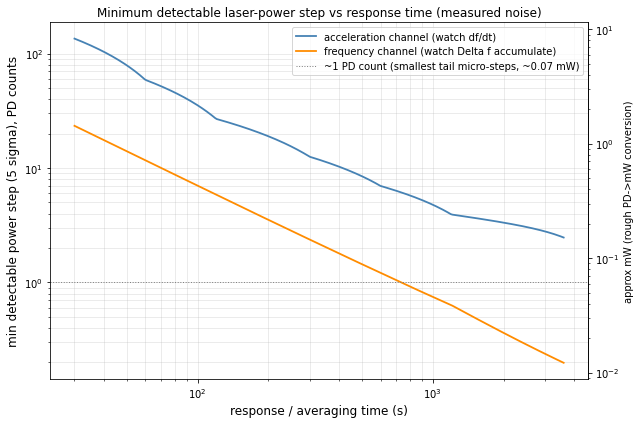

T =    60 s: accel channel    59.5 PD (~  3.65 mW) | freq channel    11.7 PD (~  0.72 mW)
T =   600 s: accel channel     7.0 PD (~  0.43 mW) | freq channel     1.2 PD (~  0.07 mW)
T =  3600 s: accel channel     2.5 PD (~  0.15 mW) | freq channel     0.2 PD (~  0.01 mW)

Context: the smallest commanded micro-steps in the run's tail are ~1-2 PD counts
(~0.07-0.15 mW). Where the curves dip below the gray line is where those become
detectable -- the direct empirical answer to sensitivity at the low-power end.


In [14]:
# -- 6.3 Minimum detectable power step vs response time ----------------------------
KAPPA_PD = 7.3545e-16    # N*m per PD count -- from laser_stepdown_forward_model.ipynb
                          # global fit; update here if that notebook is re-run
I_TOTAL_KGM2 = 1.88e-11   # kg m^2 -- momentum-simulation/thermal_noise_spindown.py (read-only)
PD_PER_MW = 16.3          # measured 2026-07-20 (pd_calibration.ipynb): anchor value;
                           # PD has +/-12-count etalon wiggle, worst at 1500-1800 counts

# Initial response to a power step dPD: df/dt = KAPPA_PD*dPD/(2*pi*I)  [Hz/s]
acc_per_pd = KAPPA_PD / (2 * np.pi * I_TOTAL_KGM2)

dpd_min_accel = NSIG * sa_fine / (acc_per_pd * np.exp(-GAMMA_FREE * T_fine))
dpd_min_freq  = NSIG * sf_fine * GAMMA_FREE / (acc_per_pd * (1 - np.exp(-GAMMA_FREE * T_fine)))

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(T_fine, dpd_min_accel, lw=1.8, color='steelblue',
          label='acceleration channel (watch df/dt)')
ax.loglog(T_fine, dpd_min_freq, lw=1.8, color='darkorange',
          label='frequency channel (watch Delta f accumulate)')
ax.axhline(1.0, color='gray', ls=':', lw=1,
           label='~1 PD count (smallest tail micro-steps, ~0.07 mW)')
ax.set_xlabel('response / averaging time (s)', fontsize=12)
ax.set_ylabel(f'min detectable power step ({NSIG:.0f} sigma), PD counts', fontsize=12)
secax = ax.secondary_yaxis('right', functions=(lambda x: x / PD_PER_MW,
                                                lambda x: x * PD_PER_MW))
secax.set_ylabel('approx mW (rough PD->mW conversion)', fontsize=10)
ax.set_title('Minimum detectable laser-power step vs response time (measured noise)')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

for T_ref in (60, 600, 3600):
    j = np.argmin(np.abs(T_fine - T_ref))
    print(f"T = {T_ref:>5.0f} s: accel channel {dpd_min_accel[j]:7.1f} PD (~{dpd_min_accel[j]/PD_PER_MW:6.2f} mW) | "
          f"freq channel {dpd_min_freq[j]:7.1f} PD (~{dpd_min_freq[j]/PD_PER_MW:6.2f} mW)")

print("\nContext: the smallest commanded micro-steps in the run's tail are ~1-2 PD counts")
print("(~0.07-0.15 mW). Where the curves dip below the gray line is where those become")
print("detectable -- the direct empirical answer to sensitivity at the low-power end.")

### 6.4 Residual PSDs vs the Thermal Floor
The remaining piece of the "data − fit → residuals → PSD" prescription: Welch PSDs
of the fixed-γ fit residuals on the settled halves of the three long plateaus,
overlaid with the thermal (fluctuation–dissipation) floor computed with the
*measured* γ and the rotor I from `momentum-simulation/thermal_noise_spindown.py`
(read-only).

What to look for:
- **Lines** = periodic disturbances (identifiable and killable) — e.g. the
  persistent ~10-min oscillation on the high-power plateau should appear near
  1.7 mHz on step 3, cleanly separated from broadband noise.
- **Slope of the continuum** = the color of the wander. σ_f(T) being flat vs
  averaging time (Section 6.1) implies ~1/f behavior; the PSD shows it directly.
- **Gap to the dashed thermal curve** = how far from thermally-limited the
  measurement is at each Fourier frequency — i.e. *where in the band* the technical
  noise lives that must be beaten to approach fN-scale torque sensing.

Caveats: the instantaneous frequency is 30 s-smoothed upstream (Section 3), so
content above ~1/30 Hz is rolled off by construction (marked); residuals are
resampled to 1 Hz for the PSD (loses nothing given that smoothing); the fit
subtracts the settling exponential, so leakage from any residual slow trend is
possible in the lowest one or two bins.

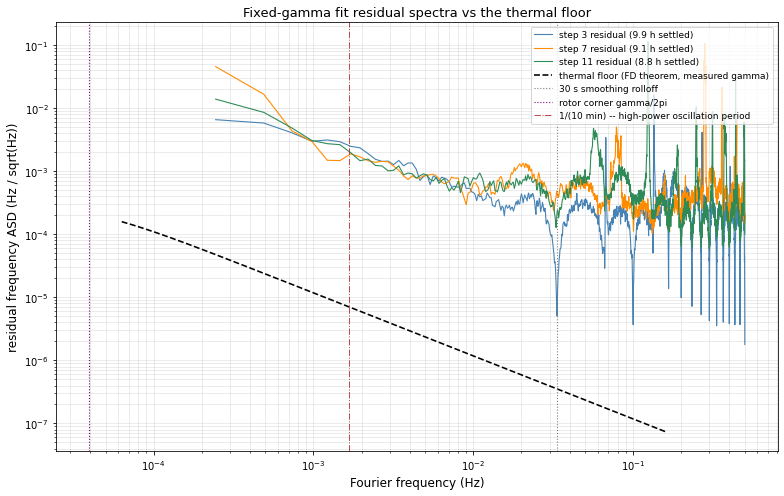

step |      ASD @ 1 mHz |     ASD @ 10 mHz | x thermal @ 1 mHz
   3 |    3.014e-03 Hz/rtHz |    4.629e-04 Hz/rtHz |               256
   7 |    2.867e-03 Hz/rtHz |    6.388e-04 Hz/rtHz |               243
  11 |    3.056e-03 Hz/rtHz |    7.926e-04 Hz/rtHz |               259


In [15]:
KB_J   = 1.380649e-23   # J/K
T_BATH = 300.0           # K
PSD_NPERSEG_S = 4096     # s at 1 Hz -> resolves down to ~2.4e-4 Hz

def thermal_asd_f(f_hz):
    """FD-theorem torque-noise floor as a one-sided ASD of spin frequency f
    (Hz/sqrt(Hz)): S_omega = 4 kB T gamma / (I (gamma^2 + (2 pi f)^2)),
    S_f = S_omega / (2 pi)^2. Uses the MEASURED free-decay gamma."""
    s_om = 4 * KB_J * T_BATH * GAMMA_FREE / (
        I_TOTAL_KGM2 * (GAMMA_FREE**2 + (2 * np.pi * f_hz)**2))
    return np.sqrt(s_om) / (2 * np.pi)

fig, ax = plt.subplots(figsize=(11, 7))
psd_colors = {3: 'steelblue', 7: 'darkorange', 11: 'seagreen'}
resid_psds = {}
for r in fit_results:
    if r['step'] not in LONG_STEPS:
        continue
    ts = r['t_fit'] - r['t_fit_start']
    resid = r['f_fit'] - model_fixed_gamma(ts, r['A_fx'], r['fss_fx'])
    half = len(resid) // 2
    t_h, res_h = r['t_fit'][half:], resid[half:]
    # uniform 1 Hz resampling (the env cut leaves tiny gaps; the 30 s upstream
    # smoothing means nothing above ~0.03 Hz survives anyway)
    tg = np.arange(t_h[0], t_h[-1], 1.0)
    rg = np.interp(tg, t_h, res_h)
    freqs, psd = welch(rg, fs=1.0, nperseg=PSD_NPERSEG_S, scaling='density')
    resid_psds[r['step']] = (freqs, psd)
    ax.loglog(freqs[1:], np.sqrt(psd[1:]), lw=1.1, color=psd_colors[r['step']],
              label=f"step {r['step']} residual ({len(rg)/3600:.1f} h settled)")

f_line = np.logspace(-4.2, -0.8, 300)
ax.loglog(f_line, thermal_asd_f(f_line), 'k--', lw=1.6,
          label='thermal floor (FD theorem, measured gamma)')
ax.axvline(1 / 30, color='gray', ls=':', lw=1.1, label='30 s smoothing rolloff')
ax.axvline(GAMMA_FREE / (2 * np.pi), color='purple', ls=':', lw=1.1,
           label='rotor corner gamma/2pi')
ax.axvline(1 / 600, color='firebrick', ls='-.', lw=1.0, alpha=0.8,
           label='1/(10 min) -- high-power oscillation period')
ax.set_xlabel('Fourier frequency (Hz)', fontsize=12)
ax.set_ylabel('residual frequency ASD (Hz / sqrt(Hz))', fontsize=12)
ax.set_title('Fixed-gamma fit residual spectra vs the thermal floor', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'step':>4} | {'ASD @ 1 mHz':>16} | {'ASD @ 10 mHz':>16} | {'x thermal @ 1 mHz':>17}")
for stp, (freqs, psd) in sorted(resid_psds.items()):
    asd1 = np.sqrt(np.interp(1e-3, freqs, psd))
    asd10 = np.sqrt(np.interp(1e-2, freqs, psd))
    print(f"{stp:>4} | {asd1:>12.3e} Hz/rtHz | {asd10:>12.3e} Hz/rtHz | "
          f"{asd1/thermal_asd_f(np.array([1e-3]))[0]:>17.0f}")

## 7. Results Summary
Single table: primary fixed-γ f_ss, float-τ diagnostic vs the 67.65-min free-decay
value, PSD peak and flags. Saved to `laser_stepdown_steps.csv` (same schema as before)
for `laser_stepdown_stability.ipynb` and `laser_stepdown_forward_model.ipynb`.

In [16]:
psd_by_step = {p['step']: p for p in psd_results}

print("=" * 122)
print(f"LASER STEP-DOWN RESULTS  (fixed-gamma primary; tau_free = {TAU_FREE_MIN} min from spindown_20260702)")
print("=" * 122)
print(f"{'step':>4} | {'level':>26} | {'hold/tau':>8} | {'f_ss fixed-g':>12} | {'resid':>7} | "
      f"{'tau_float (min)':>15} | {'PSD peak':>8} | flags")
for r in fit_results:
    pr = psd_by_step.get(r['step'])
    fpsd = f"{pr['f_global']:.3f}" if pr else "--"
    flag_str = "; ".join(pr['flags']) if (pr and pr['flags']) else "-"
    tau_str = f"{r['tau_fl']/60:.1f}" if np.isfinite(r['tau_fl']) else "--"
    print(f"{r['step']:>4} | {step_label(r['step'], steps[r['step']]):>26} | {r['hold_in_tau']:>8.2f} | "
          f"{r['fss_fx']:>12.4f} | {r['resid_fx_std']:>7.4f} | {tau_str:>15} | {fpsd:>8} | {flag_str}")

print()
print(f"Physics check: on the long holds (hold/tau >= ~2), tau_float vs {TAU_FREE_MIN} min tests the")
print("linear-drag assumption -- agreement means damping during driven operation equals free-decay")
print("damping, which is what justifies the fixed-gamma extrapolations on the short holds.")
print("Step 2 remains low-confidence (see Section 4 markdown).")

with open(STEP_TABLE_CSV, 'w', newline='') as fcsv:
    writer = csv.writer(fcsv)
    writer.writerow(['step', 'pd_level', 'counts', 'power_mw', 't_start_gps', 't_end_gps',
                      'duration_h', 'f_ss_hz', 'tau_s', 'tau_err_s',
                      'f_ss_fixed_gamma_hz', 'hold_in_tau'])
    fit_by_step2 = {r['step']: r for r in fit_results}
    for i, s in enumerate(steps):
        r = fit_by_step2.get(i)
        info = STEP_LOG_INFO.get(i, {})
        writer.writerow([
            i, s['pd_level'], info.get('counts', ''), info.get('power_mw', ''),
            s['t_start_gps'], s['t_end_gps'], s['duration_h'],
            r['f_tail'] if r else '',
            r['tau_fl'] if (r and np.isfinite(r['tau_fl'])) else '',
            r['tau_fl_err'] if (r and np.isfinite(r['tau_fl_err'])) else '',
            r['fss_fx'] if r else '', r['hold_in_tau'] if r else '',
        ])
print(f"Saved step table -> {STEP_TABLE_CSV}")

LASER STEP-DOWN RESULTS  (fixed-gamma primary; tau_free = 67.65 min from spindown_20260702)
step |                      level | hold/tau | f_ss fixed-g |   resid | tau_float (min) | PSD peak | flags
   2 |     1800 counts (12.52 mW) |     0.47 |      -4.7823 |  0.0071 |            12.1 |    2.336 | plateau-end freq far from PSD peak
   3 |     1600 counts (10.34 mW) |    17.59 |       3.8819 |  0.0756 |            66.5 |    3.867 | -
   4 |      1550 counts (9.88 mW) |     2.29 |       3.8549 |  0.0028 |             5.2 |    3.852 | -
   5 |      1500 counts (9.21 mW) |     1.03 |       3.7499 |  0.0033 |            21.1 |    3.789 | -
   6 |      1400 counts (7.97 mW) |     1.32 |       3.3081 |  0.0042 |            33.0 |    3.445 | -
   7 |      1300 counts (6.66 mW) |    16.04 |       2.7180 |  0.0063 |            66.4 |    2.719 | -
   8 |      1200 counts (5.39 mW) |     1.97 |       2.1819 |  0.0103 |            43.6 |    2.258 | -
   9 | PD=74 (unmatched tail sub-step) |     2.